<font size="6">Coding Challenge Osapiens Terra</font>

<font size="6">Visualize input data</font>

The data is from 2017 to 2023 from two countries: Brazil and Canada. The data is in the form of a 4D tensor with dimensions (time, x, y, channels). The channels are the 12 different bands of the satellite data and one quality band that indicates the quality of the image:

bands: ["B01", "B02", "B03", "B04", "B05", "B06", "B07", "B08", "B8A", "B09", "B11", "B12", "SCL"]
more information about the bands can be found [here](https://sentinel.esa.int/web/sentinel/user-guides/sentinel-2-msi/resolutions/spatial) and [here](https://docs.sentinel-hub.com/api/latest/data/sentinel-2-l2a/).


 The data is stored in the `satellite_data` folder. Each country has its own file. There are 12 time steps fore each year. The data is stored in the form of numpy arrays.

The data need to be downloaded from [Download](https://drive.google.com/drive/folders/1ttW3vF3XVhkQaoK04V5QoQ6mj9-b-Dva?usp=sharing). 
After downloading it put it in your data directory.

# Imports 

In [1]:
import pathlib
import numpy as np
import matplotlib.pyplot as plt
import rasterio
from rasterio.transform import from_bounds
import json
from matplotlib import animation
from IPython.display import HTML

# Paths

In [2]:
path_array = r"../data/features_canada.npy"
path_geojson = r"../data/area_canada.geojson"


output_folder = pathlib.Path(r"../output")
output_folder.mkdir(parents=True, exist_ok=True) 

# Load the data (Canada)

In [3]:
band_b02, band_b03, band_b04, band_b08, band_b12, band_scl = 1, 2, 3, 7, 11, 12
time_step = 4

In [4]:
array = np.load(path_array)  

time_steps, height, width, channels = array.shape

scl = array[:, :, :, -1]

In [5]:
time_steps, height, width, channels

(72, 145, 118, 13)

# Export to tif

In [6]:
# Load bounding box from GeoJSON
with open(path_geojson) as f:
    geojson = json.load(f)

# Extract bounding box coordinates
bbox = geojson["features"][0]["geometry"]["coordinates"][0]
#min_lon, min_lat, max_lon, max_lat = -62.068013710426726, 45.617395602507, -62.0526887979983, 45.63033775193736
min_lon, min_lat = bbox[1]
max_lon, max_lat = bbox[3]

# Build affine transform
transform = from_bounds(min_lon, min_lat, max_lon, max_lat, width, height)

## Full stack

In [ ]:
for t in range(time_steps):
    array_t = array[t, :, :, :]
    array_t = np.transpose(array_t, (2, 0, 1))
    path_output = output_folder / f"features_canada_{t}.tif"
    with rasterio.open(
        path_output, 'w',
        driver='GTiff',
        height=height,
        width=width,
        count=array_t.shape[0],
        dtype=array.dtype,
        crs='EPSG:4326',
        transform=transform
    ) as dst:        
        dst.write(array_t)

## True color composite

In [ ]:
for t in range(time_steps):
    array_t = array[t, :, :,  [band_b04, band_b03, band_b02]]
    path_output = output_folder / f"features_canada_{t}_TRUECOLOR.tif"
    with rasterio.open(
        path_output, 'w',
        driver='GTiff',
        height=height,
        width=width,
        count=array_t.shape[0],
        dtype=array.dtype,
        crs='EPSG:4326',
        transform=transform
    ) as dst:        
        dst.write(array_t)

## SCL

In [ ]:
for t in range(time_steps):
    array_t = array[t, :, :, [-1]]
    path_output = output_folder / f"features_canada_{t}_SLC.tif"
    with rasterio.open(
        path_output, 'w',
        driver='GTiff',
        height=height,
        width=width,
        count=array_t.shape[0],
        dtype=np.uint16,
        crs='EPSG:4326',
        transform=transform
    ) as dst:        
        dst.write(array_t)

# Visualize data

## True color composite (B04, B03, B02)

/opt/conda/lib/python3.11/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)


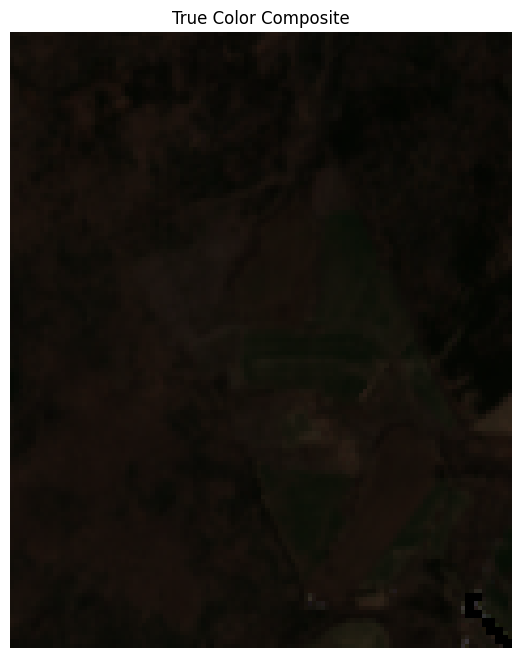

In [7]:
true_color = array[time_step, :, :, [band_b04, band_b03, band_b02]]
true_color = np.transpose(true_color, (1, 2, 0))

plt.figure(figsize=(8, 8))
plt.imshow(true_color)
plt.title("True Color Composite")
plt.axis("off")
plt.show()

## False color composite (B08, B04, B03)

In [8]:
false_color = array[time_step, :, :, [band_b08, band_b04, band_b03]]
false_color.shape

(3, 145, 118)

In [9]:
false_color = np.transpose(false_color, (1, 2, 0))
false_color.shape

(145, 118, 3)

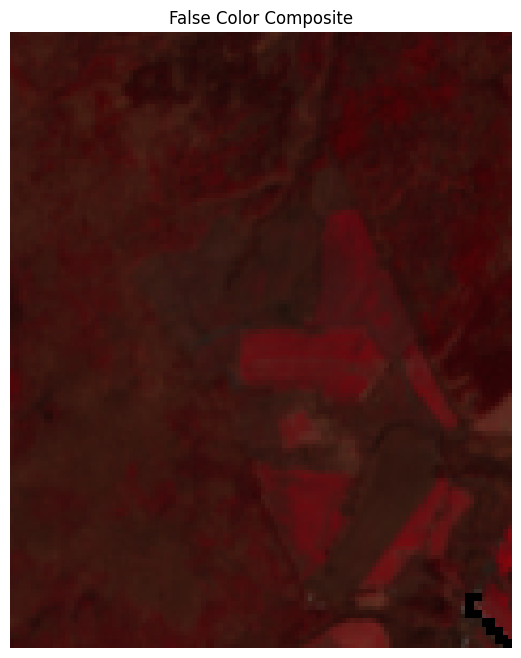

In [10]:
false_color = array[time_step, :, :, [band_b08, band_b04, band_b03]]
false_color = np.transpose(false_color, (1, 2, 0))

plt.figure(figsize=(8, 8))
plt.imshow(false_color)
plt.title("False Color Composite")
plt.axis("off")
plt.show()

## Normalized Burn Ratio (NBR = (B08 - B12) / (B08 + B12))

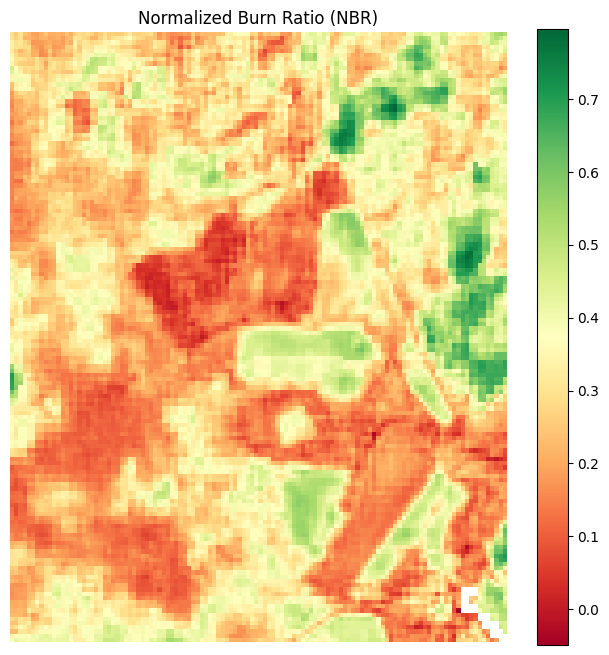

In [11]:
nbr = (array[time_step, :, :, band_b08] - array[time_step, :, :, band_b12]) / \
      (array[time_step, :, :, band_b08] + array[time_step, :, :, band_b12] + 1e-10)

plt.figure(figsize=(8, 8))
plt.imshow(nbr, cmap='RdYlGn')
plt.title("Normalized Burn Ratio (NBR)")
plt.colorbar()
plt.axis("off")
plt.show()

## Scene Classification Layer (SCL)

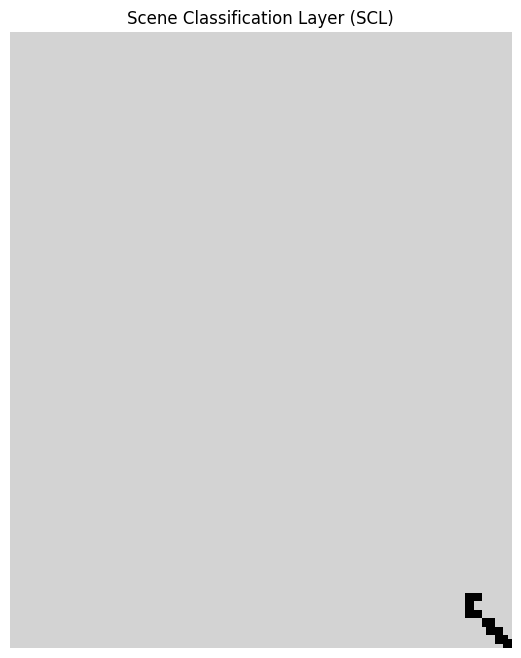

In [12]:
scl_t = array[time_step, :, :, band_scl]

# Define a color map for SCL
from matplotlib.colors import ListedColormap
scl_colors = ['lightgrey','black']
scl_cmap = ListedColormap(scl_colors)

plt.figure(figsize=(8, 8))
plt.imshow(scl_t, cmap=scl_cmap)
plt.title("Scene Classification Layer (SCL)")
plt.axis("off")
plt.show()

## "Data score layer"
How many available observations per pixel?

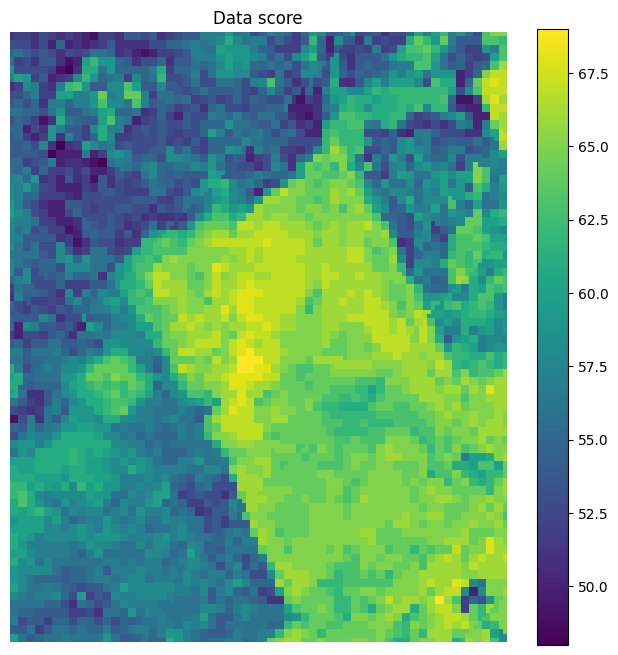

In [13]:
datascore = np.isin(scl, [0]).sum(axis=0)
plt.figure(figsize=(8, 8))

plt.imshow(datascore)
plt.title("Data score")
plt.colorbar()
plt.axis("off")
plt.show()

## Animation of true color composites over time

In [14]:
fig, ax = plt.subplots(figsize=(8, 8))
plt.close(fig)

def update(frame):
    ax.clear()
    img = array[frame, :, :, [band_b04, band_b03, band_b02]]
    img = np.transpose(img, (1,2,0))
    
    ax.imshow(img)
    ax.set_title(f"Time step: {frame}")
    ax.axis("off")

ani = animation.FuncAnimation(fig, update, frames=array.shape[0], interval=500)
HTML(ani.to_jshtml())

/opt/conda/lib/python3.11/site-packages/matplotlib/cm.py:494: RuntimeWarning: invalid value encountered in cast
  xx = (xx * 255).astype(np.uint8)
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats 